# 02 — Baseline CNN

Train the small CNN to validate the end-to-end training pipeline.  
For a full run use `python scripts/train_baseline.py` from `model/`; this notebook does a **short smoke run** (2 epochs).

**Prerequisite:** model package installed in the active kernel (see `model/README.md`).

In [34]:
REPO_ROOT = "~/code/sandinosaso/pathsight/artifacts/figures"

In [33]:
import sys
from pathlib import Path


def _add_model_src() -> Path:
    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        candidate = base / "model" / "src"
        if candidate.is_dir():
            s = str(candidate)
            if s not in sys.path:
                sys.path.insert(0, s)
            return base
    raise RuntimeError(f"Cannot find model/src from {cwd}. Run Jupyter from the repo root.")


REPO_ROOT = _add_model_src()
print("Repo root:", REPO_ROOT)

Repo root: /Users/sooheib/code/sandinosaso/pathsight


In [35]:
import os
import tensorflow as tf
from model_service.training.baseline import build_baseline_cnn
from model_service.preprocess.dataset_builder import build_pcam_datasets


In [36]:
# Create the directory if it doesn't exist
train_dir = Path(REPO_ROOT).expanduser()

if not os.path.exists(train_dir):
    os.makedirs(train_dir)
    print(f"Directory {train_dir} created successfully!")
else:
    print(f"Directory {train_dir} already exists.")

Directory /Users/sooheib/code/sandinosaso/pathsight/artifacts/figures already exists.


In [37]:
import PIL.Image as Image
import os

# Define your paths
img_path = Path(REPO_ROOT).expanduser()/ "01_sample_patches.png"
output_dir = Path(REPO_ROOT).expanduser()

# 1. Create the class folders
os.makedirs(f"{output_dir}/metastatic", exist_ok=True)
os.makedirs(f"{output_dir}/non_metastatic", exist_ok=True)

# 2. Open and Slice (Assuming 2 rows, 4 columns)
img = Image.open(img_path)
width, height = 96, 96 # Size of each individual patch

for row in range(2):
    for col in range(4):
        left = col * width
        top = row * height
        patch = img.crop((left, top, left + width, top + height))

        # Based on your photo, only row 0, col 2 is metastatic
        if row == 0 and col == 2:
            patch.save(f"{output_dir}/metastatic/patch_{row}_{col}.png")
        else:
            patch.save(f"{output_dir}/non_metastatic/patch_{row}_{col}.png")

print("✅ Slicing complete! You now have 8 individual images.")

✅ Slicing complete! You now have 8 individual images.


In [38]:
# Define paths (update these to your actual folder names)
batch_size = 32
img_height = 224
img_width = 224

# 1. Load the Training set
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(96, 96),
    batch_size=32
)

# 2. Load the Validation set
val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(96, 96),
    batch_size=32
)

Found 8 files belonging to 2 classes.
Using 7 files for training.
Found 8 files belonging to 2 classes.
Using 1 files for validation.


In [39]:
# 1. Initialize the model
# Assuming patches are 96x96 RGB images
input_shape = (96, 96, 3)
model = build_baseline_cnn(input_shape=input_shape, learning_rate=0.001)

# 2. Fit the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    verbose=1
)

Epoch 1/10


/Users/sooheib/.pyenv/versions/3.10.6/envs/pathsight/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.4286 - auc: 0.1667 - loss: 14.5451 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.8571 - auc: 0.5000 - loss: 110.6140 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.8571 - auc: 0.5000 - loss: 20.6038 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.4286 - auc: 0.2500 - loss: 68.7283 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 6.8460e-04 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.8571 - auc: 0.5000 - loss: 23.5394 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 7/

In [40]:
# Get the final scores from the last epoch
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print(f"Final Training Accuracy: {final_train_acc * 100:.2f}%")
print(f"Final Validation Accuracy: {final_val_acc * 100:.2f}%")

Final Training Accuracy: 57.14%
Final Validation Accuracy: 100.00%


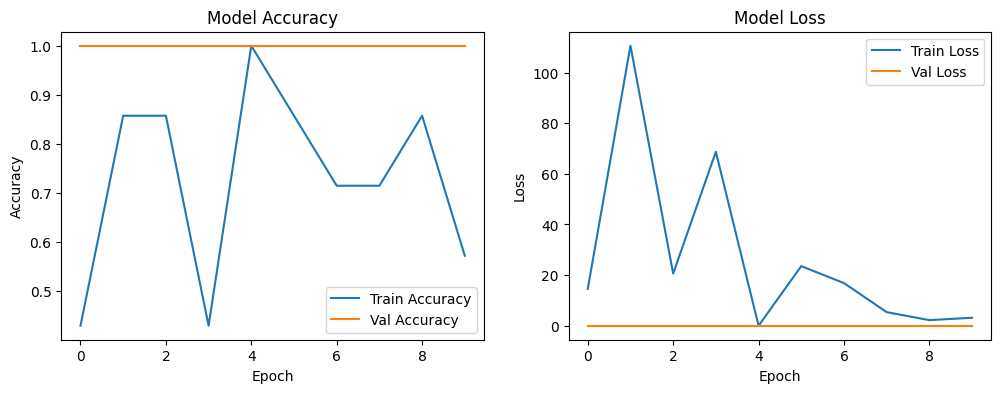

In [41]:
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

to_save=Path(REPO_ROOT).expanduser() / "training_scores.png"
# SAVE the score to your folder
plt.savefig(to_save)
img_path = Path(REPO_ROOT).expanduser()/ "01_sample_patches.png"

plt.show()

In [ ]:
from model_service.config import ModelServiceConfig
from model_service.preprocess.loaders import build_pcam_datasets
from model_service.evaluation.plots import plot_history
from model_service.training.baseline import build_baseline_cnn
from model_service.training.callbacks import default_callbacks
from model_service.training.train import run_training

In [3]:
cfg = ModelServiceConfig()
cfg.data.batch_size = 32
cfg.train.epochs = 2   # smoke run — increase for real training

train_ds, val_ds, _, _ = build_pcam_datasets(
    cfg, download=True, use_efficientnet_preprocess=False
)
model = build_baseline_cnn()
model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,817 (432.88 KB)

 Trainable params: 110,817 (432.88 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Absolute paths so saving works wherever Jupyter was launched
models_dir   = REPO_ROOT / "artifacts" / "models"
metrics_dir  = REPO_ROOT / "artifacts" / "metrics"
figures_dir  = REPO_ROOT / "artifacts" / "figures"
for d in [models_dir, metrics_dir, figures_dir]:
    d.mkdir(parents=True, exist_ok=True)

cbs = default_callbacks(
    models_dir  / "baseline_nb.keras",
    metrics_dir / "baseline_nb.csv",
    monitor="val_auc",
    mode="max",
    early_stopping_patience=3,
)

hist = run_training(model, train_ds, val_ds, epochs=cfg.train.epochs, callbacks=cbs)
plot_history(hist, figures_dir / "baseline_nb_history.png")
print("Training complete. Best checkpoint:", models_dir / "baseline_nb.keras")

Epoch 1/2
8192/8192 ━━━━━━━━━━━━━━━━━━━━ 3672s 448ms/step - accuracy: 0.8099 - auc: 0.8907 - loss: 0.4177 - precision: 0.8047 - recall: 0.8183 - val_accuracy: 0.8046 - val_auc: 0.9006 - val_loss: 0.4124 - val_precision: 0.8419 - val_recall: 0.7496
Epoch 2/2
8192/8192 ━━━━━━━━━━━━━━━━━━━━ 3704s 452ms/step - accuracy: 0.8615 - auc: 0.9352 - loss: 0.3253 - precision: 0.8588 - recall: 0.8653 - val_accuracy: 0.8348 - val_auc: 0.9246 - val_loss: 0.3659 - val_precision: 0.8793 - val_recall: 0.7759
Training complete. Best checkpoint: /Users/sandinosaso/repos/pathsight/artifacts/models/baseline_nb.keras
